In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


<Axes: xlabel='tip_amount', ylabel='Count'>

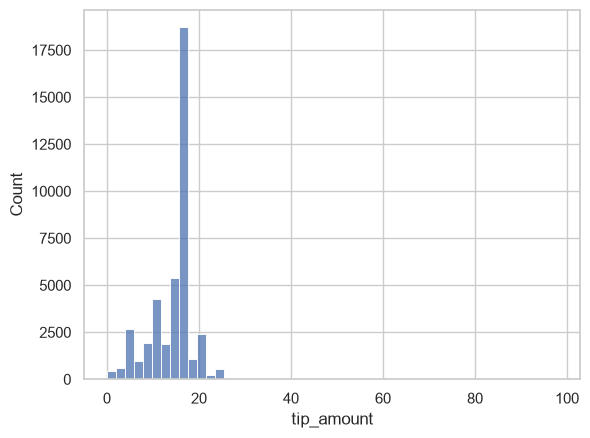

In [2]:
taxi = pd.read_csv(TAXI_URL)

taxi.shape, taxi.head(), taxi.info()
taxi.describe()
taxi.isna().sum()

sns.histplot(data=taxi, x="tip_amount",bins=50)

Student Reasoning:
The data set has 41,202 rows and 13 columns so its shape is (41202,13) and there are not any missing values or impossible values in the data because every column has 41,202 not null entries. The distribution is right skewed with not many outliers and zeros. Preprocessing will focus more on identifying and handling invalid records and outliers.

In [3]:
# Dropping missing values
taxi = taxi.dropna()

# removing invalid rows
taxi= taxi[(taxi["trip_distance"] > 0)& (taxi["fare_amount"] >0)]

# feature engineering
taxi["total_surcharges"] = (taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"])

# categorical columns
categorical_columns = ["VendorID", "RatecodeID","payment_type","store_and_fwd_flag"]
categorical_columns = ["PULocationID", "DOLocationID"]
taxi=pd.get_dummies(taxi,columns = categorical_columns, drop_first=True)



# Scaling the numeric features
from sklearn.preprocessing import StandardScaler


Student Reasoning
1.I handled invalid rows by removing trip distances and fare amounts where were less than or equal to zero. 
2.I created a new feature called total surcharges which combines all the additional extra charges into a single cost thus making it easier to capture the entire cost of the trip. 
3.I used the Standard scaler so that numeric features have a mean of 0 and standard deviation of 1 becasuse without using this larger values could have a greater influence on the model than features with smaller values regardless of importance

In [5]:
X= taxi.drop("tip_amount", axis=1)
y= taxi["tip_amount"]

RANDOM_STATE = 42
from sklearn.model_selection import train_test_split
X_temp,X_test,y_temp,y_test = train_test_split(X,y, test_size=0.2,random_state = RANDOM_STATE)
X_train, X_val,y_train,y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=RANDOM_STATE)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled= scaler.transform(X_test)


Student Reasoning
1.I split the dataset into 60% training ,20% validation, 20% testing.

2.The separate validation set is used to compare model and adjust certain things as the model is being built but the test is used when the model has been completed and is used to measure how well the model will perform with new and unseen data which will give us a true evaluation of how well the model is likely to perform.

3.The scaler must be fit only to the training data so that is prevent data leakage which is when the model accidentally gets information from the validation or test set during training. If it doesnt the training process would have been influenced with that information thus leading to performance estimates which may not be valid.



Linear Regression Validation MAE: 3.574725452388949
Training MAE: 3.527903962986185
Training RMSE: 4.776435030509537
Training R²: 0.06236019914100954

Validation MAE: 3.574725452388949
Validation RMSE: 5.046530557146512
Validation R²: 0.04508275029340392

Test MAE: 3.579437022976175
Test RMSE: 5.01686203816882
Test R²: 0.04966720438374539
Training MAE: 1.9241091253555644
Training RMSE: 2.843435178302853
Training R²: 0.6677117775221078

Validation MAE: 3.909636257145458
Validation RMSE: 5.6557420501901925
Validation R²: -0.1993863763138528

Test MAE: 3.932506567760401
Test RMSE: 5.634535550622098
Test R²: -0.19874731409504487


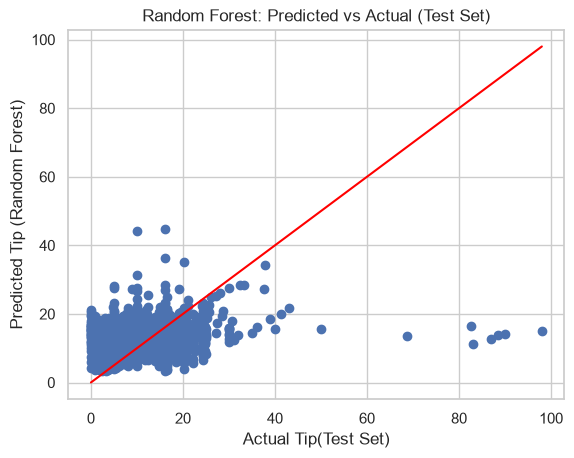

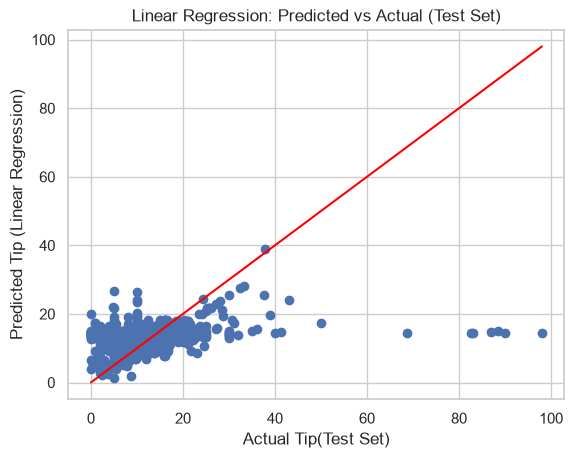

In [7]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Evaluation
from sklearn.metrics import mean_absolute_error

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

train_preds_lr = linear_model.predict(X_train_scaled)
val_preds_lr = linear_model.predict(X_val_scaled)
test_preds_lr = linear_model.predict(X_test_scaled)

print("Linear Regression Validation MAE:",
      mean_absolute_error(y_val, val_preds_lr))


print("Training MAE:", mean_absolute_error(y_train, train_preds_lr))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, train_preds_lr)))
print("Training R²:", r2_score(y_train, train_preds_lr))

print()

print("Validation MAE:", mean_absolute_error(y_val, val_preds_lr))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_preds_lr)))
print("Validation R²:", r2_score(y_val, val_preds_lr))

print()

print("Test MAE:", mean_absolute_error(y_test, test_preds_lr))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds_lr)))
print("Test R²:", r2_score(y_test, test_preds_lr))

# Random Forest
from sklearn.ensemble import RandomForestRegressor
randomf_model = RandomForestRegressor(n_estimators =100, random_state= RANDOM_STATE)
randomf_model.fit(X_train_scaled,y_train)

# Evaluation
train_preds_rf = randomf_model.predict(X_train_scaled)
val_preds_rf = randomf_model.predict(X_val_scaled)
test_preds_rf = randomf_model.predict(X_test_scaled)

print("Training MAE:", mean_absolute_error(y_train, train_preds_rf))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, train_preds_rf)))
print("Training R²:", r2_score(y_train, train_preds_rf))

print()

print("Validation MAE:", mean_absolute_error(y_val, val_preds_rf))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_preds_rf)))
print("Validation R²:", r2_score(y_val, val_preds_rf))

print()

print("Test MAE:", mean_absolute_error(y_test, test_preds_rf))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds_rf)))
print("Test R²:", r2_score(y_test, test_preds_rf))



plt.scatter(y_test, test_preds_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Tip(Test Set)")
plt.ylabel("Predicted Tip (Random Forest)")
plt.title("Random Forest: Predicted vs Actual (Test Set)")
plt.show()

plt.scatter(y_test, test_preds_lr)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Tip(Test Set)")
plt.ylabel("Predicted Tip (Linear Regression)")
plt.title("Linear Regression: Predicted vs Actual (Test Set)")
plt.show()

Student Reasoning
1.The Linear Regression model performed better on the validation set because it had a lower MAE, RMSE and a higher R*2 compared to the Random Forest model. 
2.For linear regression the performance is similar across the data sets however the low R*2 value (MAE ≈ 3.53–3.58, R² ≈ 0.04–0.06)shows that the model is underfitting but for Random Forest the training performance is much better(MAE = 1.92, R² = 0.67) than the validation test performance(MAE ≈ 3.9, R² ≈ -0.20) so this gap shows that the model is overfitting
3.I would make the model less complex so that it just doesnt memorize the training data by for example limit how deep the trees in the Random Forest can grow.



<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

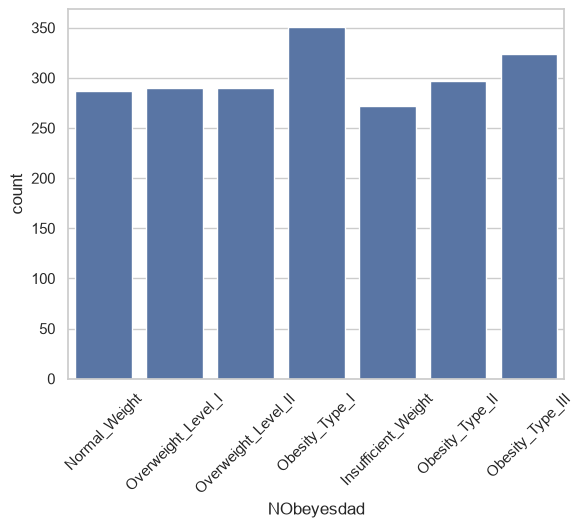

In [8]:
import pandas as pd
obesity = pd.read_csv(OBESITY_URL)
obesity.shape,obesity.head(), obesity.info()
obesity.describe()
obesity.isna().sum()

print(obesity["NObeyesdad"].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=obesity, x="NObeyesdad")
plt.xticks(rotation=45)
plt.show()




Student Reasoning
There are 2111 rows and 17 
Numeric columns (8):
Age
Height
Weight
FCVC
NCP
CH2O
FAF
TUE

Categorical columns (9):
Gender
family_history_with_overweight
FAVC
CAEC
SMOKE
SCC
CALC
MTRANS
NObeyesdad

The target is slightly imbalanced, with some classes having more samples than others.Class imbalance matters because the model may favor majority classes and perform poorly on minority ones which leads to inaccuracy



In [ ]:

# Encode categorical columns
binary_columns = ["family_history_with_overweight","FAVC","SMOKE","SCC"]
for columns in binary_columns:
    obesity[columns] = obesity[columns].map({"yes" : 1,"no": 0})

# Ordinal columns
from sklearn.preprocessing import OrdinalEncoder
# Ordinal Encoder is used because CAEC and CALC both increase in terms of frequency so they have a natural order
ordinal_columns = ["CAEC","CALC"]
# Encoding
encoder = OrdinalEncoder()
obesity[ordinal_columns]= encoder.fit_transform(obesity[ordinal_columns])


# Nominal columns & encoding
# Gender and MTRANS used pd.get_dummies because there is no order and one hot coding ensures an ordinal relationship is not assumed between the categories
obesity = pd.get_dummies(obesity, columns = ["Gender", "MTRANS"], drop_first = True)


# feature engineering
obesity["BMI"]= (obesity["Weight"] / obesity["Height"]**2 )

from sklearn.preprocessing import LabelEncoder
label_e = LabelEncoder()
obesity["NObeyesdad"]= label_e.fit_transform(obesity["NObeyesdad"])



Studenty Reasoning
1.I encoded the categorical variables as 0 and 1 because they only have two variables. I used ordinal encoder for CALC and CAEC becuse their categories have natural order and I used one hot encoding for gender and mtrans because the have no natural order then i used label encoder to convert the target into integer class labels
2.I created a BMI feature using weight and height but eventhough it is related to obesity, calculating it uses existing features in the dataset which dont use the target directly.
3.I used Standard Scaler because it puts the numeric features on a similar scale, helping the model learn more effectively.

In [ ]:
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

from sklearn.model_selection import train_test_split
X_train,X_temp,y_train,y_temp = train_test_split(X,y, test_size=0.4,random_state = RANDOM_STATE,stratify = y)
X_val, X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=RANDOM_STATE,stratify =y_temp)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled= scaler.transform(X_test)

1.I used a 60% training, 20% validation, and 20% test split
2.This is because it ensure that each dataset has similar proportion of the 7 obesity classes as the original data set
3.some classes may have imbalances with samples in the training,validation or test set which could lead to biased results and lower performance of the model

Training Accuracy: 0.915481832543444
Training Macro F1: 0.912167785768823

Validation Accuracy: 0.8862559241706162
Validation Macro F1: 0.8838410386761087

Test Accuracy: 0.8888888888888888
Test Macro F1: 0.8838779799778422

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        54
           1       0.82      0.69      0.75        58
           2       1.00      0.90      0.95        70
           3       0.94      0.98      0.96        60
           4       0.98      1.00      0.99        65
           5       0.78      0.72      0.75        58
           6       0.77      0.91      0.83        58

    accuracy                           0.89       423
   macro avg       0.89      0.89      0.88       423
weighted avg       0.89      0.89      0.89       423



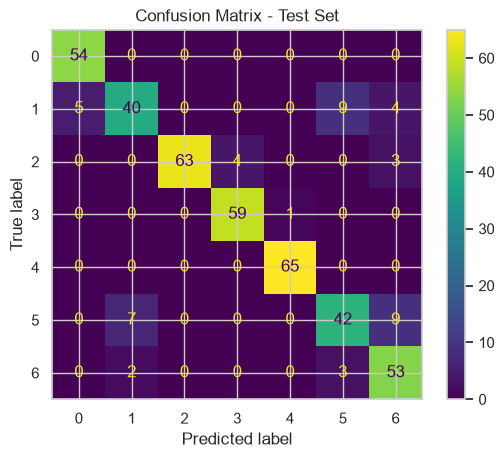

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

# Training predictions
y_train_pred = model.predict(X_train_scaled)

# Validation predictions
y_val_pred = model.predict(X_val_scaled)

# Test predictions
y_test_pred = model.predict(X_test_scaled)

# Reporting accuracy and cacro-F1 for all three sets
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Training Accuracy:" , accuracy_score(y_train,y_train_pred))
print("Training Macro F1:", f1_score(y_train, y_train_pred, average ="macro"))
print()

print("Validation Accuracy:", accuracy_score(y_val,y_val_pred))
print("Validation Macro F1:",f1_score(y_val,y_val_pred, average ="macro"))
print()

print("Test Accuracy:", accuracy_score(y_test,y_test_pred))
print("Test Macro F1:",f1_score(y_test,y_test_pred, average ="macro"))
print()

print("Classification Report (Test Set):")
print(classification_report(y_test,y_test_pred))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred)
plt.title("Confusion Matrix - Test Set")
plt.show()


Student Reasoning
1.I used the Logistic Regression because it is an effecftive yet simple classifier for multi class classification and it is fast to train and easy to interpret
2.The model appears to be well-fitted because the training, validation, and test results are very similar. The training accuracy is 91.5%, while the validation and test accuracies are 88.6% and 88.9%, respectively. The Macro F1 scores are also close (0.91, 0.88, and 0.88), showing that the model generalizes well
3.The hardest obesity levels to tell apart are the neighbouring classes such overweight and obesity levels and this is so because the classes have similar characteristics making it harder to differentiate

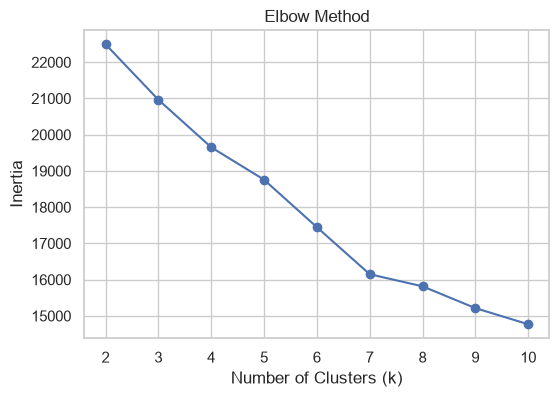

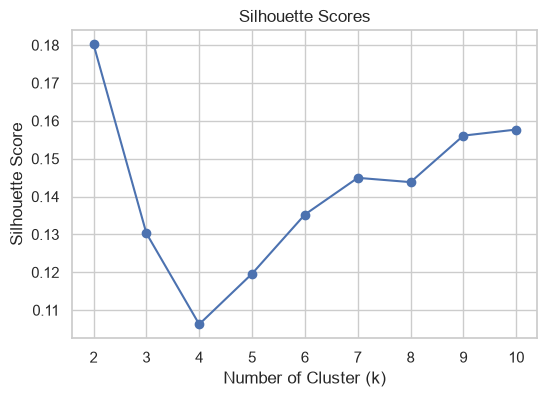

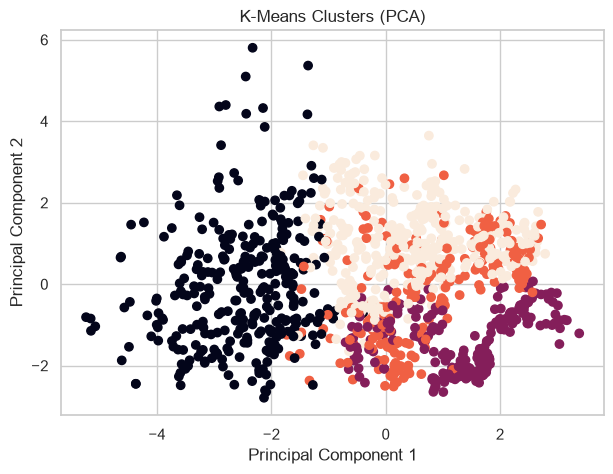

In [ ]:

X_cluster = X_train_scaled

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = RANDOM_STATE)
    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_cluster,labels))

# Visualising the clusters in 2D

plt.figure(figsize=(6,4))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette, marker="o")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

kmeans = KMeans(n_clusters=4, random_state =RANDOM_STATE)
cluster_labels= kmeans.fit_predict(X_cluster)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7,5))
plt.scatter( X_pca[:,0], X_pca[:,1], c=cluster_labels)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA)")
plt.show()

Student Reasoning
1.I used the elbow methods and silhouette score so I chose k=4
2.The clusters are similar to the obesity levels in some cases, but they do not match exactly. They agree where people with similar characteristics are grouped together, but they break down because some obesity levels have overlapping features, causing different classes to appear in the same cluster.
3.The cluster could be used to identify groups of people with similar characteristics thus being able to identify people who for example may be at risk and give more information when certain levels are not available